In [1]:
import jax
import jax.numpy as jnp
from jax import random, jit, vmap
from jax.nn import sigmoid, softplus
import mcfile as mcf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def free_energy(W, bv, bh, v):
    """F(v; θ) per sample. Shape: (batch,)"""
    # softplus(x) is numerically identical to stable log(1 + exp(x))
    return -(v @ bv) - softplus(v @ W.T + bh).sum(axis=-1)

def hidden_probs(W, bh, v):
    return sigmoid(v @ W.T + bh)

def visible_probs(W, bv, h):
    return sigmoid(h @ W + bv)

def sample(probs, key):
    return random.bernoulli(key, p=probs).astype(probs.dtype)

@jit
def pseudo_likelihood(W, bv, bh, v):
    """Computes the log pseudo-likelihood log PL(v) for a batch of visible vectors."""
    n_visible = W.shape[1]
    
    # Pre-compute original free energy once, rather than re-computing inside the vmap
    fe_orig = free_energy(W, bv, bh, v)
    
    def pl_for_unit(i):
        # Broadcast the flip condition across the batch dimension
        v_flipped = jnp.where(jnp.arange(n_visible) == i, 1.0 - v, v)
        fe_flipped = free_energy(W, bv, bh, v_flipped)
        return -jnp.logaddexp(0, fe_orig - fe_flipped)

    # vmap over the visible unit indices (axis 0 of the output)
    log_p_vi = vmap(pl_for_unit)(jnp.arange(n_visible)) # Shape: (n_visible, batch)
    
    # Sum across all visible units to get log PL for each sample, then mean over batch
    return log_p_vi.sum(axis=0)

@jit
def pcd_step(W, bv, bh, v0, chains, lr, weight_decay, key):
    k1, k2 = random.split(key)
    batch_size = v0.shape[0]

    # Positive phase
    ph0 = hidden_probs(W, bh, v0)

    # Negative phase — one Gibbs step on persistent chains
    ph_chain = hidden_probs(W, bh, chains)
    h_chain  = sample(ph_chain, k1)
    
    pv_chain = visible_probs(W, bv, h_chain)
    chains   = sample(pv_chain, k2)
    
    ph_neg   = hidden_probs(W, bh, chains)

    # Gradients
    dW  = (ph0.T @ v0 - ph_neg.T @ chains) / batch_size
    dbv = (v0 - chains).mean(axis=0)
    dbh = (ph0 - ph_neg).mean(axis=0)

    # Updates with L2 weight decay
    W  = W + lr * dW - weight_decay * W
    bv = bv + lr * dbv
    bh = bh + lr * dbh

    return W, bv, bh, chains

@jit
def compute_metrics_batch(W, bv, bh, v0, key):
    """Processes a single batch for metrics to avoid memory bottlenecks."""
    k1, k2 = random.split(key)
    
    fe0 = free_energy(W, bv, bh, v0)
    log_pl = pseudo_likelihood(W, bv, bh, v0)

    # One Gibbs step → v1
    ph1 = hidden_probs(W, bh, v0)
    h1  = sample(ph1, k1)
    
    pv1 = visible_probs(W, bv, h1)
    v1  = sample(pv1, k2)

    fe1 = free_energy(W, bv, bh, v1)
    
    return {
        "pl": log_pl.mean(),
        "fe": fe0.mean(),
        "cd": (fe0 - fe1).mean(),
        "recon": jnp.mean((v0 - v1) ** 2)
    }

In [3]:
def init_rbm(n_visible, n_hidden, key):
    k1, k2 = random.split(key)
    scale = jnp.sqrt(2 / (n_visible + n_hidden))
    W  = random.normal(k1, (n_hidden, n_visible)).astype(jnp.float32) * scale
    bv = jnp.zeros(n_visible, dtype=jnp.float32)
    bh = jnp.zeros(n_hidden,  dtype=jnp.float32)
    
    return W, bv, bh, k2

def init_chains(n_chains, n_visible, key):
    k1, k2 = random.split(key)
    chains = random.bernoulli(k1, p=0.5, shape=(n_chains, n_visible)).astype(jnp.float32)
    return chains, k2

In [4]:


def train(W, bv, bh, train_data, test_data, epochs=500, batch_size=32,
          lr=0.005, weight_decay=1e-4, monitor_every=10, alpha=0.1, key=None):
    """
    Trains the RBM while tracking Exponentially Weighted Moving Averages (EWMA)
    of training and validation performance metrics.
    """

    k_chain, k_loop = random.split(key)
    n_train = len(train_data)
    
    chains, k_chain = init_chains(batch_size, W.shape[1], k_chain)

    header = f"{'epoch':>6}  {'train_PL':>12}  {'val_PL':>12}  {'tr_recon':>10}  {'val_recon':>10} {'tr_fe':>10}  {'val_fe':>10} {'tr_cd':>10}  {'val_cd':>10}"
    print(header)
    print("─" * len(header))

    history = []
    ewma_metrics = {}

    # update EWMA dictionaries 
    def update_ewma(prefix, current_ewma, new_metrics):
        for metric_name, val in new_metrics.items():
            key_name = f"{prefix}_{metric_name}"
            val = float(val)
            if key_name not in current_ewma:
                current_ewma[key_name] = val
            else:
                current_ewma[key_name] = (1 - alpha) * current_ewma[key_name] + alpha * val

    # Convert test data to JAX array once (assuming it fits in memory)
    test_data = jnp.array(test_data, dtype=jnp.float32)

    for epoch in range(1, epochs + 1):
        k_loop, k_perm, k_step, k_val = random.split(k_loop, 4)
        
        # Random sampling without replacement
        idx = random.permutation(k_perm, n_train)
        
        for start in range(0, n_train, batch_size):
            batch_idx = idx[start : start + batch_size]
            if len(batch_idx) < batch_size:
                continue
            
            batch = jnp.array(train_data[batch_idx], dtype=jnp.float32)
            k_step, subkey, k_metric = random.split(k_step, 3)
            
            # Step the optimization
            W, bv, bh, chains = pcd_step(W, bv, bh, batch, chains,
                                         lr, weight_decay, subkey)
            
            # Calculate and update training metrics
            train_metrics = compute_metrics_batch(W, bv, bh, batch, k_metric)
            update_ewma("train", ewma_metrics, train_metrics)

        # Calculate and update validation metrics across the test split
        val_metrics = compute_metrics_batch(W, bv, bh, test_data, k_val)
        update_ewma("val", ewma_metrics, val_metrics)

        # Capture current running snapshot
        history.append({"epoch": epoch, 'metrics': ewma_metrics.copy()})
        
        if epoch % monitor_every == 0 or epoch == 1:
            m = ewma_metrics
            print(f"{epoch:>6}  "
                  f"{m.get('train_pl', 0):>12.4f}  {m.get('val_pl', 0):>12.4f}  "
                  f"{m.get('train_recon', 0):>10.4f}  {m.get('val_recon', 0):>10.4f} "
                  f"{m.get('train_fe', 0):>10.4f}  {m.get('val_fe', 0):>10.4f} "
                  f"{m.get('train_cd', 0):>10.4f}  {m.get('val_cd', 0):>10.4f}")

    return W, bv, bh, history

In [5]:
b_c = 0.440687
sector = 'PP'
L = 24

datadir = "../ising_mcdata"
data = mcf.build_dataframe(datadir)
bc_num = data['beta'][np.argmin(np.abs(np.array(data['beta'])-b_c))]
snapshots = data.query('beta == @bc_num and sector == @sector and Lx == @L and Ly == @L')['spins']
snapshots = jnp.squeeze(jnp.array(np.stack(snapshots.to_numpy())))

Processing files: 100%|█| 320/320 [00:12<00:00, 26.19file/s, L56_beta0.443000_se


In [19]:
def bernoullise(spin_data):
    ''' convert  pm1 to 1,0 respectively'''
    spin_data = (spin_data > 0.0).astype(np.float32)
    return spin_data

def train_test_split(raw_data,train_frac=0.8, to_bernoullise=True):
    if to_bernoullise:
        raw_data= bernoullise(raw_data)
    shuffled_indices = np.random.permutation(len(raw_data))
    split_idx = int(train_frac * len(raw_data))
    train_data = raw_data[shuffled_indices[:split_idx]]
    test_data = raw_data[shuffled_indices[split_idx:]]
    
    return train_data, test_data

def reshape_and_truncate(data, remove_before = 2000):
    data = data.reshape(len(data), -1)
    data = data[remove_before:]
    return data

In [20]:
snapshots = reshape_and_truncate(snapshots)
train_data, test_data = train_test_split(snapshots)

In [21]:
n_hidden = 256
batch_size = 64
epochs = 40
monitor_every = 4
alpha = 0.15

rng = random.PRNGKey(42)
W, bv, bh, rng = init_rbm(n_visible=train_data.shape[1], n_hidden=n_hidden, key=rng)
W, bv, bh, history = train(W, bv, bh, train_data, test_data,
                           epochs=epochs, monitor_every = monitor_every, batch_size=batch_size, alpha=alpha, key=rng)

 epoch      train_PL        val_PL    tr_recon   val_recon      tr_fe      val_fe      tr_cd      val_cd
────────────────────────────────────────────────────────────────────────────────────────────────────────
     1     -186.6227     -130.1368      0.2316      0.1472  -906.0094  -1209.1462   -74.3045    -62.7802
     4     -119.3006     -126.1831      0.1050      0.1320 -1544.7353  -1328.4928    -8.5841    -43.4186
     8     -119.6868     -122.9546      0.1011      0.1175 -1597.2540  -1454.9524     0.1569    -23.6493
    12     -119.5804     -121.2393      0.1010      0.1091 -1604.2987  -1526.3241     0.0908    -12.2552
    16     -119.6697     -120.3537      0.1009      0.1049 -1602.0966  -1561.8198     0.0640     -6.5771
    20     -119.4444     -119.8905      0.1009      0.1027 -1601.3437  -1580.6399    -0.3357     -3.3485
    24     -119.0685     -119.6547      0.1009      0.1017 -1599.3415  -1589.9900    -1.0536     -1.9858
    28     -119.3513     -119.5307      0.1004      0.1

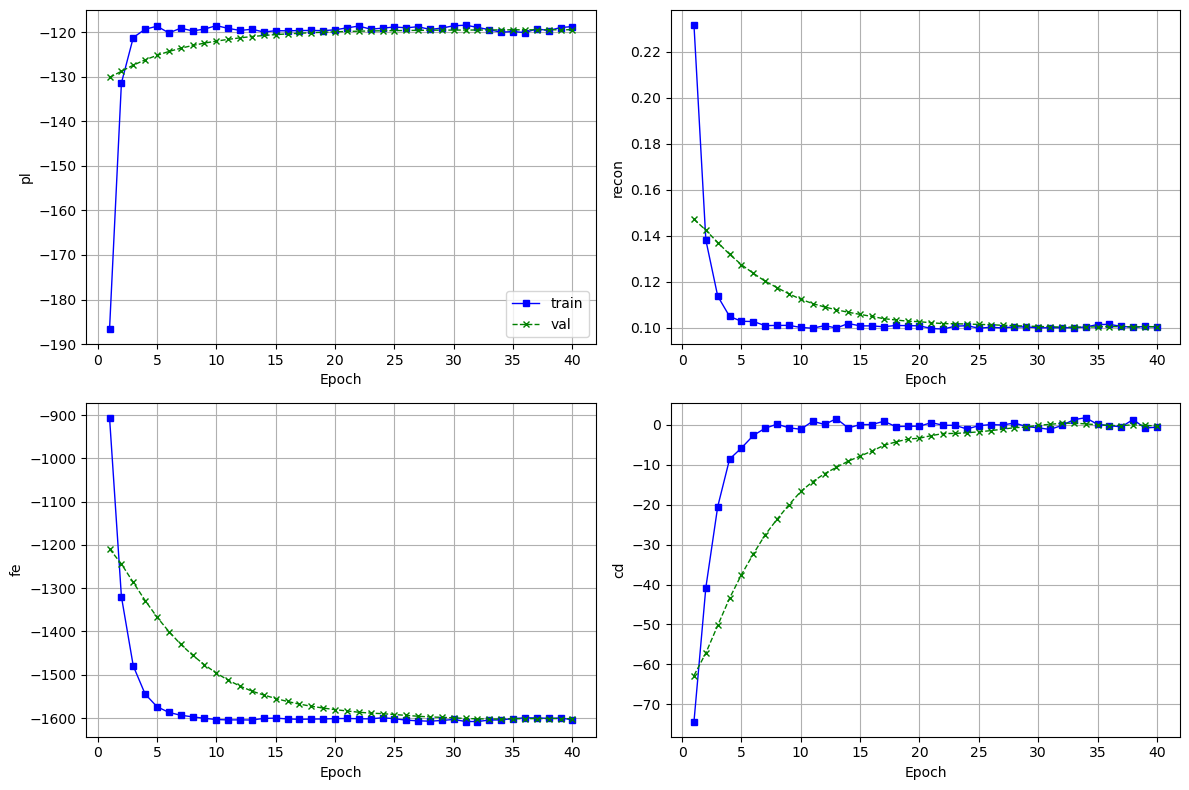

In [22]:
def plot_metrics(history, metric_keys=("pl", "recon", "fe", "cd")):
    """
    Plots training and validation EWMA metrics over epochs.
    
    Parameters
    ----------
    history : list of dicts
        Each dict has 'epoch', 'train', 'val' keys.
    metric_keys : tuple
        The metrics to plot.
    """
    epochs = [h["epoch"] for h in history]
    
    plt.figure(figsize=(12, 8))
    
    for i, metric in enumerate(metric_keys, 1):
        plt.subplot(2, 2, i)
        

        train_vals = [h["metrics"][f"train_{metric}"] for h in history]
        val_vals   = [h["metrics"][f"val_{metric}"] for h in history]
        
        epochs = [h["epoch"] for h in history]
        
        plt.plot(epochs, train_vals, label="train", color='blue', marker='s', linestyle='solid',
                 linewidth=1, markersize=5)
        plt.plot(epochs, val_vals, label="val", color='green', marker='x', linestyle='dashed',linewidth=1, markersize=5)
        
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)

        if i == 1:
            plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_metrics(history)